# Part 9 — Deep Learning for Sequences

**PyTimeSeries user guide** · *From-scratch LSTM / TCN / Seq2Seq via pt.deep (kept small for speed).*

> Uses the `pytimeseries` package on the shared commodity-price dataset.

In [1]:
import warnings; warnings.simplefilter("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pytimeseries as pt
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Shared dataset: 356 months of global commodity prices (1992-2021)
raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]); df.index = dates
df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]
print("pytimeseries", pt.__version__, "| series:", list(df.columns))

pytimeseries 0.5.0 | series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


`pt.deep` provides PyTorch sequence models behind the same contract. We use small configs here so the notebook renders quickly.

In [2]:
fits = {}
for name, M in [('LSTM', pt.deep.LSTMForecaster(lags=12, epochs=60)),
                ('TCN',  pt.deep.TCNForecaster(lags=12, epochs=60))]:
    fits[name] = M.fit(y).predict(12)
seq = pt.deep.Seq2SeqForecaster(lags=12, horizon=12, epochs=80).fit(y).predict(12)
print('LSTM[:3]', fits['LSTM'].round(1).head(3).tolist(), '| Seq2Seq len', len(seq))

LSTM[:3] [119.5, 117.9, 116.3] | Seq2Seq len 12


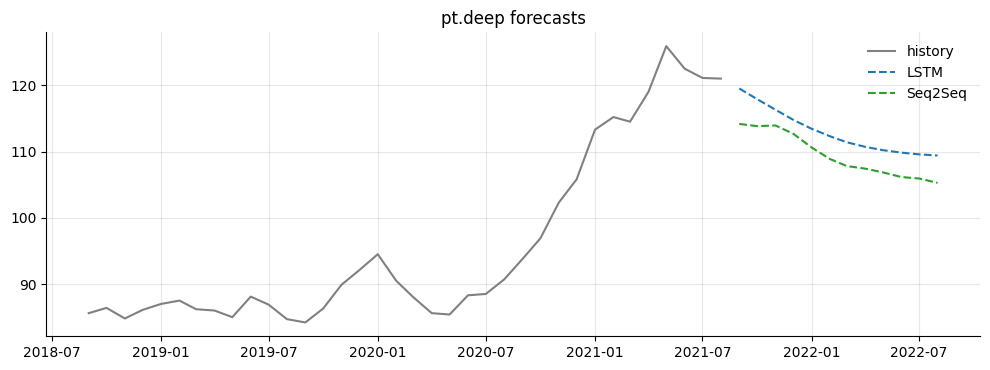

In [3]:
fig, ax = plt.subplots()
ax.plot(y.index[-36:], y.iloc[-36:], color='0.5', label='history')
ax.plot(fits['LSTM'].index, fits['LSTM'], 'C0--', label='LSTM')
ax.plot(seq.index, seq, 'C2--', label='Seq2Seq')
ax.set_title('pt.deep forecasts'); ax.legend(frameon=False); plt.tight_layout(); plt.show()

**Takeaway.** Neural sequence models slot into the same `fit/predict` API; wrap them with `pt.ConformalForecaster` for intervals.